In [582]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [583]:
data  = pd.read_csv('ecommerce_sales_analytics_5000.csv')

In [584]:
data.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [585]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


1. order_date needs to be in date_time format


In [586]:
data.isna().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [587]:
data.shape

(5000, 12)

Questions : 
1. which hpaymenthod is used more
2. is there any relation between discount and customer satisfication
3. which kind of payment method gives us more revenue
4. is there any relation between region and delivery days
5. which product_category gives us more revenue
6. unit price effecting any customer satifaction
7. which region buys more of certain product category
8. does heavy quantiy help get the unit price less 
9. like which order_date had heavy discount 
10. which region uses which kind payment method
11. is delivery days effecting the revnue

In [588]:
data.describe()

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
std,1443.520003,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219
min,10001.000000,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000


In [589]:
data.duplicated().sum()

np.int64(0)

In [590]:
data['region'].value_counts()

region
West     1289
North    1276
East     1227
South    1208
Name: count, dtype: int64

In [591]:
data['product_category'].value_counts()

product_category
Electronics    1777
Clothing       1531
Home            969
Beauty          723
Name: count, dtype: int64

In [592]:
data['customer_rating'].corr(data.delivery_days)

np.float64(-0.01762494227644025)

In [593]:
data['product_category'].value_counts(normalize=True)

product_category
Electronics    0.3554
Clothing       0.3062
Home           0.1938
Beauty         0.1446
Name: proportion, dtype: float64

In [594]:
df = data.copy()
df.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='object')

In [595]:
df

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,14996,9/5/2035,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74
4996,14997,9/6/2035,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47
4997,14998,9/7/2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06
4998,14999,9/8/2035,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38


In [596]:
df['product_category'].unique()

array(['Beauty', 'Clothing', 'Electronics', 'Home'], dtype=object)

In [597]:
df['region'].unique()

array(['South', 'East', 'West', 'North'], dtype=object)

In [598]:
df['payment_method'].unique()

array(['Wallet', 'Card', 'COD'], dtype=object)

In [599]:
check_revenue = df.groupby('product_category')['revenue'].sum()
sort_revenue = check_revenue.reset_index().sort_values('revenue',ascending=False)
sort_revenue

,product_category,revenue
2,Electronics,1829899.22
1,Clothing,1531931.72
3,Home,982083.92
0,Beauty,765860.88


<Axes: xlabel='product_category'>

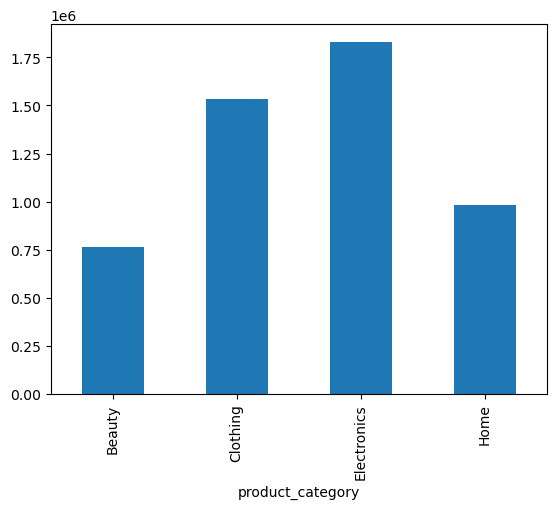

In [600]:
df.groupby('product_category')['revenue'].sum().plot(kind='bar')

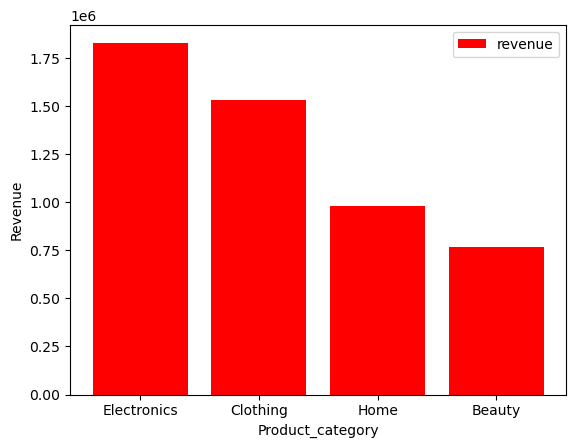

In [601]:
plt.bar(sort_revenue["product_category"],sort_revenue["revenue"] , color = 'red' , label = 'revenue')
plt.xlabel('Product_category')
plt.ylabel('Revenue')
plt.legend()
plt.show()

Insights : 
- Electronics generate 35% of the revenue, Clothing generate 30% percent of the revenue, Home generate  19% of the revenue and Beauty generated 14% of the revenue , so here the clear stats show that Electronic generate more number of revenue 

In [602]:
percentage = (sort_revenue['revenue']/sort_revenue['revenue'].sum()) * 100
percentage

2    35.811733
1    29.980410
3    19.219707
0    14.988151
Name: revenue, dtype: float64

## Which product category sold the highest quantity of products?

In [603]:
category_quantity = df.groupby('product_category')['quantity'].sum()
sort_quantity = category_quantity.reset_index().sort_values('quantity', ascending=False)
sort_quantity

,product_category,quantity
2,Electronics,7109
1,Clothing,6171
3,Home,3949
0,Beauty,2995


In [604]:
category_quantity.idxmax(),category_quantity.max()

('Electronics', 7109)

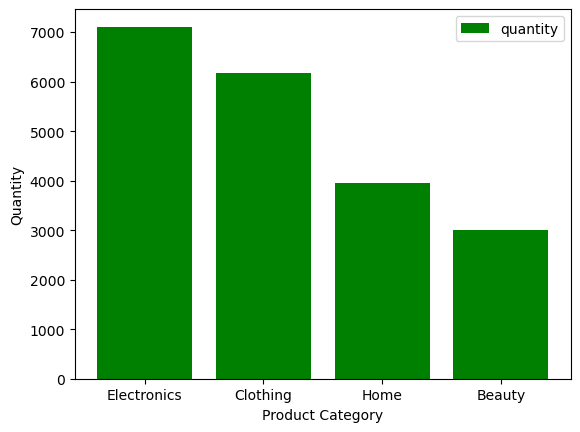

In [605]:
plt.bar(sort_quantity['product_category'], sort_quantity['quantity'], color = 'green' ,label = 'quantity')
plt.xlabel("Product Category")
plt.ylabel("Quantity")
plt.legend()
plt.show()

Insight : quantity of the product is relativily related to revenue so that is both the revenue and quantity gave the same equation and percetages

## Which region generated the highest revenue

In [606]:
region_revenue = df.groupby('region')['revenue'].sum()
sort_region = region_revenue.reset_index().sort_values('region' , ascending=False)
sort_region

,region,revenue
3,West,1345582.16
2,South,1246640.90
1,North,1281508.45
0,East,1236044.23


In [607]:
percentage = sort_region['revenue']/ sort_region['revenue'].sum() * 100
percentage

3    26.333488
2    24.397174
1    25.079544
0    24.189794
Name: revenue, dtype: float64

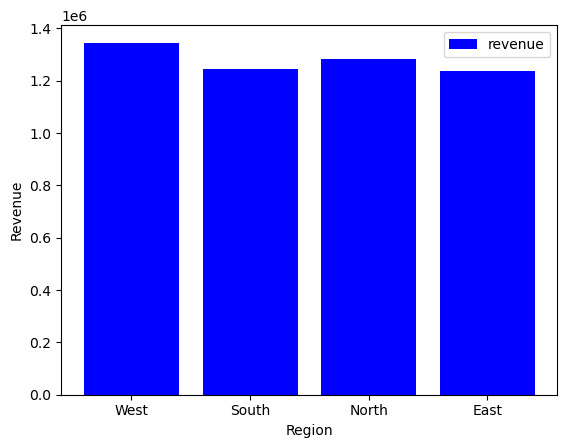

In [608]:
plt.bar(sort_region['region'],sort_region['revenue'] , color = 'blue' , label = 'revenue')
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.legend()
plt.show()

Insights : The West has created more number of revenue

## Which region sold the highest quantity of products?

In [609]:
region_Product = df.groupby('region')['quantity'].sum()
sort_Product = region_Product.reset_index().sort_values('region' , ascending=False)
sort_Product

,region,quantity
3,West,5260
2,South,4884
1,North,5164
0,East,4916


In [610]:
percentage = sort_Product['quantity'] / sort_Product['quantity'].sum() * 100
percentage

3    26.008703
2    24.149525
1    25.534019
0    24.307753
Name: quantity, dtype: float64

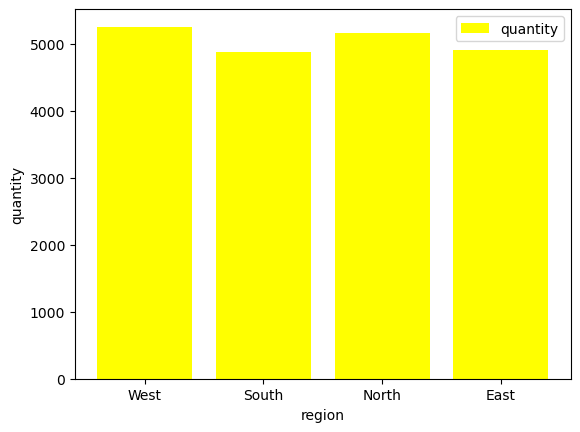

In [611]:
plt.bar(sort_Product['region'],sort_Product['quantity'] , color = 'yellow' ,label = 'quantity')
plt.xlabel("region")
plt.ylabel("quantity")
plt.legend()

## Which region had the highest average customer rating?

In [612]:
region_customer_rating = df.groupby('region')['customer_rating'].mean()
sort_rating = region_customer_rating.reset_index().sort_values("customer_rating", ascending=False)
sort_rating



,region,customer_rating
1,North,2.993182
0,East,2.973187
2,South,2.967798
3,West,2.961521


In [613]:
df['customer_rating'].dtype

dtype('float64')

In [614]:
print(region_customer_rating.idxmax() , region_customer_rating.max())
print(region_customer_rating.idxmin() , region_customer_rating.min())

North 2.993181818181818
West 2.961520558572537


## Which region had the fastest delivery service?

In [615]:
region_delivery= df.groupby('region')['delivery_days'].mean()
sort_delivery= region_delivery.reset_index().sort_values("delivery_days", ascending=False)
sort_delivery



,region,delivery_days
2,South,6.173013
1,North,6.118339
0,East,6.104319
3,West,6.082234


## Which payment method generated the highest revenue?

In [616]:
region_payment_method= df.groupby('payment_method')['revenue'].mean()
sort_payment= region_payment_method.reset_index().sort_values("revenue", ascending=False)
sort_payment



,payment_method,revenue
1,Card,1042.400088
0,COD,1008.122007
2,Wallet,999.078556


In [617]:
percentage = sort_payment['revenue'] / sort_payment['revenue'].sum() * 100
percentage

1    34.181528
0    33.057509
2    32.760964
Name: revenue, dtype: float64

<BarContainer object of 3 artists>

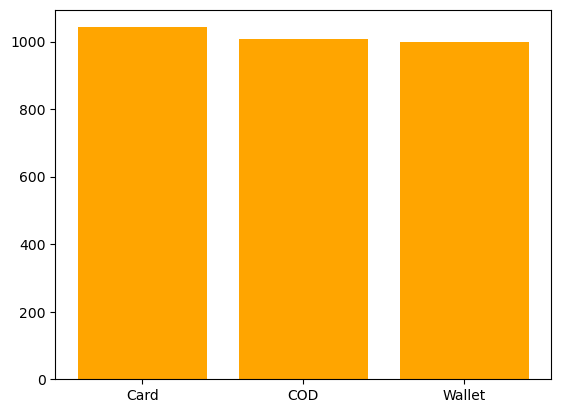

In [618]:
plt.bar(sort_payment['payment_method'] , sort_payment['revenue'], color = "Orange" , label = 'revenue' )

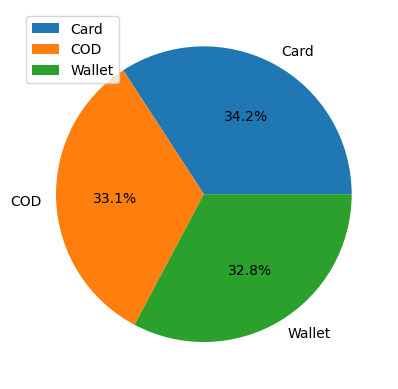

In [619]:
plt.pie(sort_payment['revenue'] , labels = sort_payment['payment_method'] , autopct='%1.1f%%')
plt.legend()
plt.show()

## Which payment method had the highest average order value?

Order value is directly correlated with revenue so it is same as the above charts

In [620]:
region_payment_method= df.groupby('payment_method')['revenue'].mean()
sort_payment= region_payment_method.reset_index().sort_values("revenue", ascending=False)
sort_payment



,payment_method,revenue
1,Card,1042.400088
0,COD,1008.122007
2,Wallet,999.078556


## Which product category received the highest customer ratings?

In [621]:
product_customer_rating= df.groupby('product_category')['customer_rating'].mean()
custmoer_rating= product_customer_rating.reset_index().sort_values("customer_rating", ascending=False)
custmoer_rating



,product_category,customer_rating
0,Beauty,3.008990
1,Clothing,3.005095
2,Electronics,2.951097
3,Home,2.940660


## Does faster delivery lead to higher customer ratings?¶

In [622]:
fast_del= df.groupby('delivery_days')['customer_rating'].mean()
fast_rating= fast_del.reset_index().sort_values("customer_rating", ascending=False)
fast_rating



,delivery_days,customer_rating
3,4,3.071308
4,5,3.044310
6,7,3.024632
0,1,2.988636
7,8,2.985501
5,6,2.963617
8,9,2.953846
1,2,2.935849
2,3,2.931463
9,10,2.924593


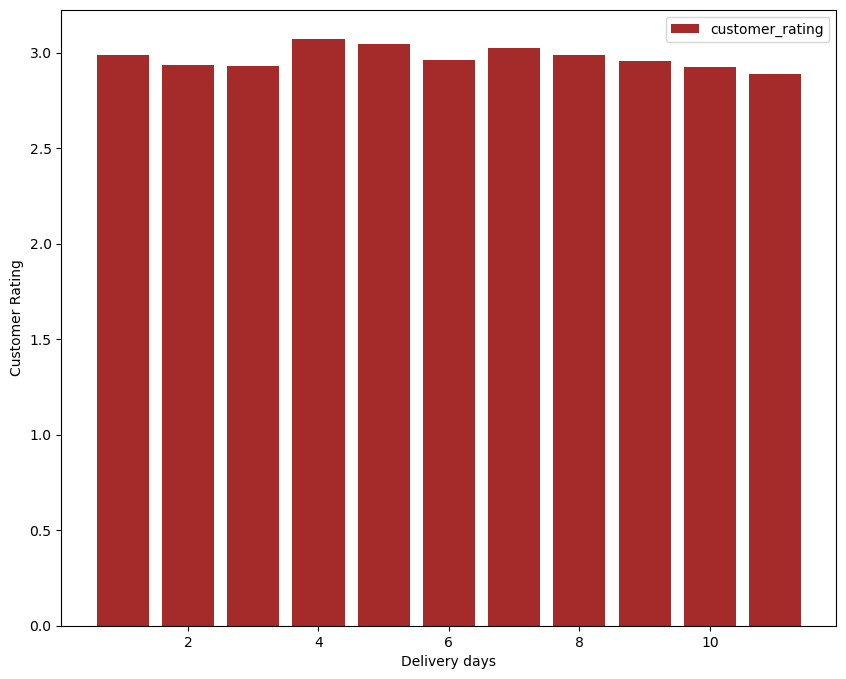

In [623]:
plt.figure(figsize =(10,8))
plt.bar(fast_rating['delivery_days'],fast_rating['customer_rating'] , color = 'brown' , label = 'customer_rating')
plt.xlabel("Delivery days")
plt.ylabel("Customer Rating")
plt.legend()
plt.show()

In [624]:
df['order_date'] = pd.to_datetime(df['order_date'],errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5000 non-null   int64         
 1   order_date        5000 non-null   datetime64[ns]
 2   customer_id       5000 non-null   int64         
 3   product_category  5000 non-null   object        
 4   region            5000 non-null   object        
 5   quantity          5000 non-null   int64         
 6   unit_price        5000 non-null   float64       
 7   discount          5000 non-null   float64       
 8   payment_method    5000 non-null   object        
 9   delivery_days     5000 non-null   int64         
 10  customer_rating   5000 non-null   float64       
 11  revenue           5000 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(4), object(3)
memory usage: 468.9+ KB


In [625]:
df['month'] = df['order_date'].dt.month_name()

In [626]:
df['month']

0         January
1         January
2         January
3         January
4         January
          ...    
4995    September
4996    September
4997    September
4998    September
4999    September
Name: month, Length: 5000, dtype: object

<Axes: >

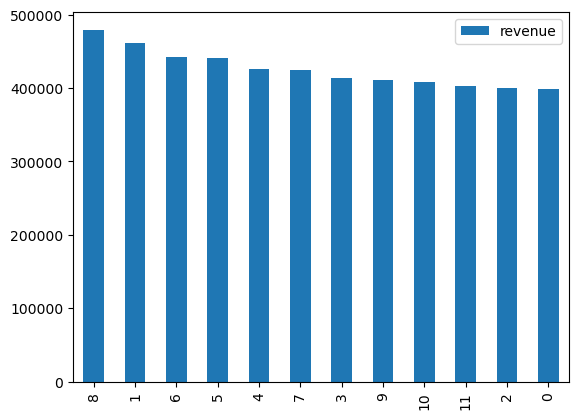

In [627]:
month_revenue= df.groupby('month')['revenue'].sum()
sort_month= month_revenue.reset_index().sort_values("revenue", ascending=False)
sort_month.plot(kind='bar')



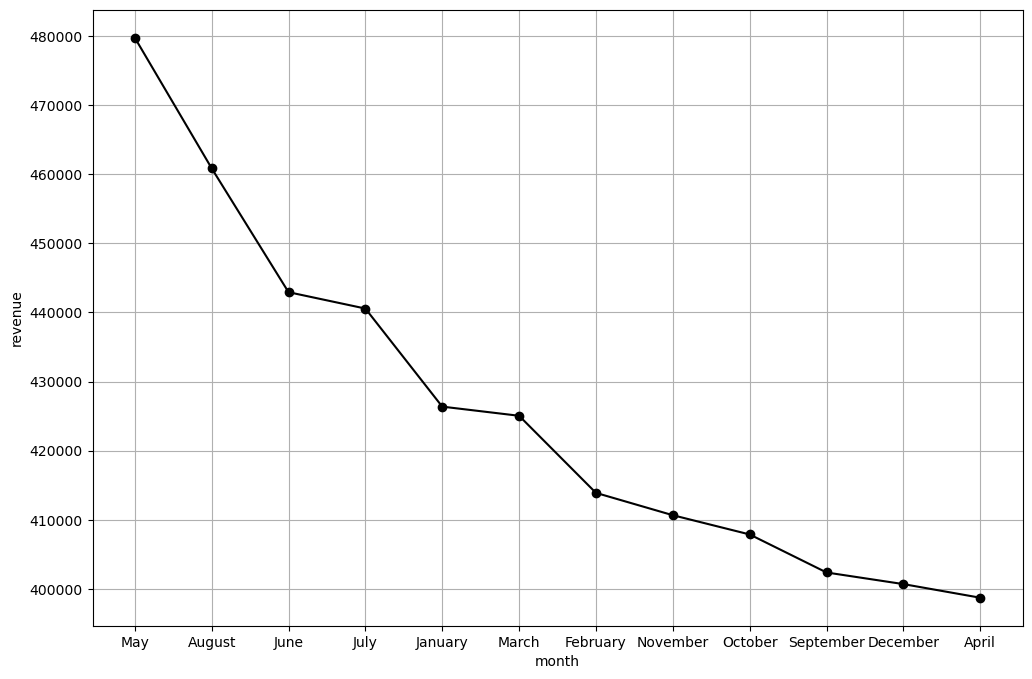

In [628]:
plt.figure(figsize=(12,8))
plt.plot(sort_month['month'], sort_month['revenue'], color = 'black', label = 'revenue' , marker = 'o' )
plt.xlabel("month")
plt.ylabel("revenue")
plt.grid()

## Which month received the highest number of orders?

In [629]:
order_number= df.groupby('month')['order_id'].count()
sort_order= order_number.reset_index().sort_values("order_id", ascending=False)
sort_order



,month,order_id
1,August,434
4,January,434
5,July,434
7,March,434
8,May,434
0,April,420
6,June,420
2,December,403
10,October,403
11,September,399


In [630]:
print(order_number.idxmax(),order_number.max())
print(order_number.idxmin(),order_number.min())

August 434
November 390


<Axes: xlabel='month'>

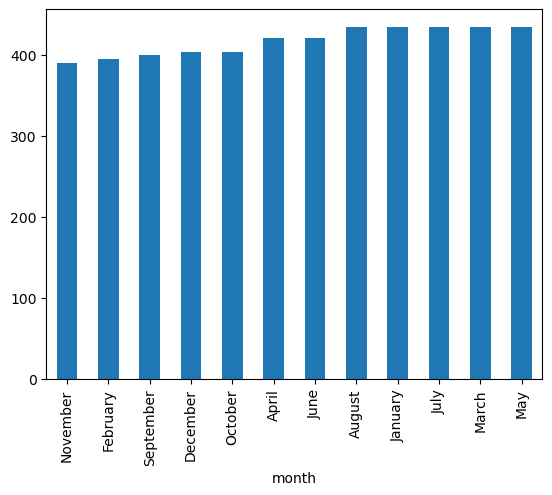

In [631]:
order_number.sort_values().plot(kind='bar')

## Which product category generated the highest revenue per unit sold?

In [632]:
df['revenue_per_unit'] = df['revenue'] / df['quantity']

In [633]:
category_revenue = df.groupby('product_category')['revenue_per_unit'].mean()
category_revenue

product_category
Beauty         249.259588
Clothing       247.670089
Electronics    258.984150
Home           251.594715
Name: revenue_per_unit, dtype: float64

In [634]:
print(category_revenue.idxmax(),category_revenue.max())
print(category_revenue.idxmin(),category_revenue.min())

Electronics 258.98414966369216
Clothing 247.67008876862306


 ## Which delivery speed category achieved the highest customer satisfaction?

In [635]:
bins = [0,3,8,12]
labels = ['Fast' , 'Medium' , 'Slow']
df['delivery_group'] = pd.cut(df['delivery_days'], bins= bins, labels=labels)


In [636]:
speed_cate = df.groupby('delivery_group')['customer_rating'].mean()
speed_cate

/var/folders/qw/_nk9z1hd74q9vjp80k85r5l80000gn/T/ipykernel_93409/460830251.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  speed_cate = df.groupby('delivery_group')['customer_rating'].mean()


delivery_group
Fast      2.952669
Medium    3.017085
Slow      2.922702
Name: customer_rating, dtype: float64

In [637]:
print(speed_cate.idxmax(),speed_cate.max())
print(speed_cate.idxmin(),speed_cate.min())

Medium 3.0170847750865053
Slow 2.922701555869873


<Axes: xlabel='delivery_group'>

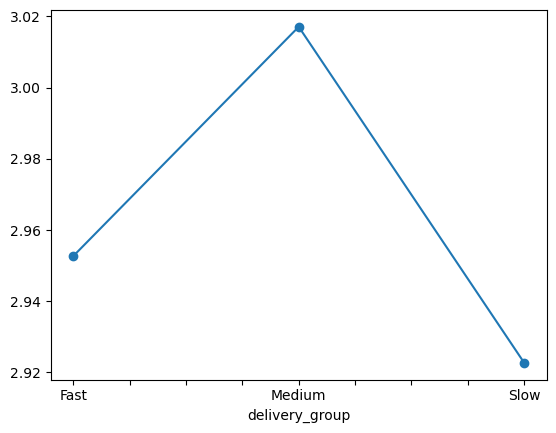

In [638]:
speed_cate.plot(kind='line' , marker = 'o')

## Show how may customers with ratings greater than 4.5.

In [639]:
customer = df[df['customer_rating'] > 4.5]
customer.shape[0]

559

## Show how many orders with delivery days greater than 8.

In [640]:
slow_deliveries = df[df['delivery_group'] == 'Slow']
slow_deliveries.shape[0]

1414

## Show how many Electronics orders with customer ratings above 4.5.

In [641]:
elec_orders = df[(df['product_category'] == 'Electronics') & (df['customer_rating'] > 4.5)]
elec_orders.shape[0]


179

## Which product category performs best in each region?¶


In [642]:
df.pivot_table(
    index='product_category',
    columns='region',
    values='revenue',
    margins=True,
    aggfunc='sum'
)

region,East,North,South,West,All
product_category,,,,,
Beauty,174909.11,186213.32,191073.98,213664.47,765860.88
Clothing,402582.60,364659.43,348363.14,416326.55,1531931.72
Electronics,411803.35,472450.93,487055.68,458589.26,1829899.22
Home,246749.17,258184.77,220148.10,257001.88,982083.92
All,1236044.23,1281508.45,1246640.90,1345582.16,5109775.74


## Which payment method is preferred for different product categories?

In [643]:
df.pivot_table(
    index='payment_method',
    columns='product_category',
    values='order_id',
    margins=True,
    aggfunc='count'
)

product_category,Beauty,Clothing,Electronics,Home,All
payment_method,,,,,
COD,258,533,622,361,1774
Card,339,708,816,407,2270
Wallet,126,290,339,201,956
All,723,1531,1777,969,5000


## How do product sales change over time?¶

In [644]:
df.pivot_table(
    index='month',
    columns='product_category',
    values='revenue',
    margins=True,
    aggfunc='sum'
)

product_category,Beauty,Clothing,Electronics,Home,All
month,,,,,
April,39455.50,123210.16,154478.50,81571.00,398715.16
August,82322.87,131432.01,169834.39,77285.51,460874.78
December,53098.31,126413.49,138194.09,82980.27,400686.16
February,65004.57,108872.67,138075.57,101937.43,413890.24
January,59428.79,142127.58,136576.44,88242.11,426374.92
July,69238.90,149814.41,131984.28,89533.13,440570.72
June,68418.43,109450.45,171833.11,93239.59,442941.58
March,60888.89,117258.01,154515.39,92388.23,425050.52
May,72619.08,152210.96,178558.59,76383.92,479772.55


In [645]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue', 'month', 'revenue_per_unit',
       'delivery_group'],
      dtype='object')

In [646]:
correlation = df[['quantity','unit_price','discount','delivery_days','customer_rating','revenue','revenue_per_unit']].corr()
correlation

,quantity,unit_price,discount,delivery_days,customer_rating,revenue,revenue_per_unit
quantity,1.000000,0.001498,-0.004302,-0.008748,0.019168,0.623564,-0.000316
unit_price,0.001498,1.000000,0.013215,0.015623,0.005025,0.678032,0.968318
discount,-0.004302,0.013215,1.000000,-0.000382,0.012776,-0.139296,-0.205799
delivery_days,-0.008748,0.015623,-0.000382,1.000000,-0.017625,0.005444,0.013785
customer_rating,0.019168,0.005025,0.012776,-0.017625,1.000000,0.012446,0.002473
revenue,0.623564,0.678032,-0.139296,0.005444,0.012446,1.000000,0.697731
revenue_per_unit,-0.000316,0.968318,-0.205799,0.013785,0.002473,0.697731,1.000000


([<matplotlib.axis.YTick at 0x30b434b90>,
 [Text(0, 0, 'quantity'),
  Text(0, 1, 'unit_price'),
  Text(0, 2, 'discount'),
  Text(0, 3, 'delivery_days'),
  Text(0, 4, 'customer_rating'),
  Text(0, 5, 'revenue'),
  Text(0, 6, 'revenue_per_unit')])

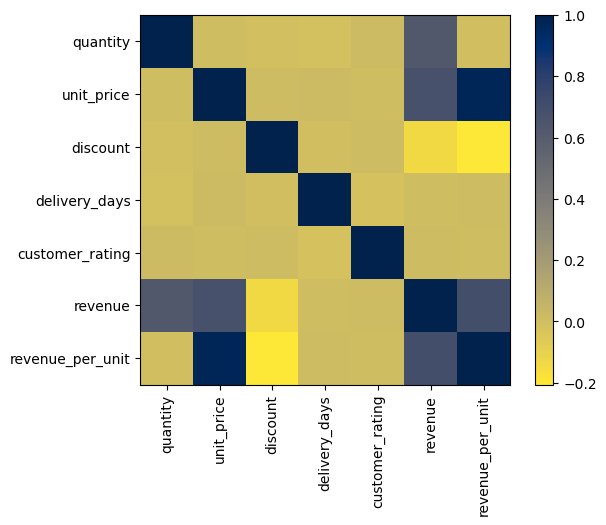

In [ ]:
plt.imshow(correlation).cmap = "cividis_r"
plt.colorbar()
plt.xticks([0,1,2,3,4,5,6],['quantity','unit_price','discount','delivery_days','customer_rating','revenue','revenue_per_unit'],rotation = 90)
plt.yticks([0,1,2,3,4,5,6],['quantity','unit_price','discount','delivery_days','customer_rating','revenue','revenue_per_unit'])